# **Week 2 — ICS-Flow Dataset Exploration & Network Graph Construction**

**Project:** Graph-Based Risk Assessment for Cyber-Physical Systems   
**Dataset:** ICS-Flow — Anomaly Detection Dataset for Industrial Control Systems (Dehlaghi-Ghadim et al., IEEE Access, 2023)    
**Goal for this notebook:** Load the ICS-Flow network flow data, inspect its structure, build an asset-level communication graph with NetworkX, and produce an initial visualization showing which devices communicate and which device pairs carried attack traffic.

This is the first concrete implementation step toward the project's knowledge-graph layer — the graph built here represents the network communication layer that will later be enriched with process-variable nodes, MITRE ATT&CK technique nodes, and CVE data in Neo4j.

## **1. Setup and Dataset Download**

Downloads the ICS-Flow dataset from Kaggle.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alirezadehlaghi/icssim")
print("Path to dataset files:", path)

100%|██████████| 443M/443M [00:02<00:00, 174MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/alirezadehlaghi/icssim/versions/2


## **2. Inspect Downloaded Files**

Lists every file in the downloaded dataset folder so we can confirm what is available (network flows, PLC snapshots, raw PCAP, etc.) before deciding what to use this week.

In [12]:
import os

for root, dirs, files in os.walk(path):
    print("\nFolder:", root)
    for file in files:
        print(file)


Folder: /root/.cache/kagglehub/datasets/alirezadehlaghi/icssim/versions/2
attacker_machine_summary.csv
snapshots_PLC2.csv
snapshots_PLC1.csv
traffic.pcap
attacker_summary.csv
Dataset.csv


**Decision for Week 2:** use only `Dataset.csv` — already in CSV format, easy to load with pandas, and sufficient for exploratory analysis and an initial graph. `attacker_summary.csv`, `attacker_machine_summary.csv`, the PLC snapshot files, and `traffic.pcap` are left for later weeks (attack-path analysis and knowledge-graph enrichment).

## **3. Load `Dataset.csv`**



Loads the main flow-record file and inspects its shape, columns, and first rows.

In [13]:
import pandas as pd

df = pd.read_csv(f"{path}/Dataset.csv")

print(df.shape)
print(df.columns)
df.head()

(45718, 64)
Index(['sAddress', 'rAddress', 'sMACs', 'rMACs', 'sIPs', 'rIPs', 'protocol',
       'startDate', 'endDate', 'start', 'end', 'startOffset', 'endOffset',
       'duration', 'sPackets', 'rPackets', 'sBytesSum', 'rBytesSum',
       'sBytesMax', 'rBytesMax', 'sBytesMin', 'rBytesMin', 'sBytesAvg',
       'rBytesAvg', 'sLoad', 'rLoad', 'sPayloadSum', 'rPayloadSum',
       'sPayloadMax', 'rPayloadMax', 'sPayloadMin', 'rPayloadMin',
       'sPayloadAvg', 'rPayloadAvg', 'sInterPacketAvg', 'rInterPacketAvg',
       'sttl', 'rttl', 'sAckRate', 'rAckRate', 'sUrgRate', 'rUrgRate',
       'sFinRate', 'rFinRate', 'sPshRate', 'rPshRate', 'sSynRate', 'rSynRate',
       'sRstRate', 'rRstRate', 'sWinTCP', 'rWinTCP', 'sFragmentRate',
       'rFragmentRate', 'sAckDelayMax', 'rAckDelayMax', 'sAckDelayMin',
       'rAckDelayMin', 'sAckDelayAvg', 'rAckDelayAvg', 'IT_B_Label',
       'IT_M_Label', 'NST_B_Label', 'NST_M_Label'],
      dtype='object')


,sAddress,rAddress,sMACs,rMACs,sIPs,rIPs,protocol,startDate,endDate,start,...,sAckDelayMax,rAckDelayMax,sAckDelayMin,rAckDelayMin,sAckDelayAvg,rAckDelayAvg,IT_B_Label,IT_M_Label,NST_B_Label,NST_M_Label
0,192.168.0.11,192.168.0.21,02:42:c0:a8:00:0b,02:42:c0:a8:00:15,192.168.0.11,192.168.0.21,IPV4-TCP,2022-09-16 11:14:39.510337,2022-09-16 11:14:40.010330,1.663320e+09,...,0.001,0.497,0.0,0.0,0.000219,0.031154,0,Normal,0,Normal
1,192.168.0.12,192.168.0.21,02:42:c0:a8:00:0c,02:42:c0:a8:00:15,192.168.0.12,192.168.0.21,IPV4-TCP,2022-09-16 11:14:39.513421,2022-09-16 11:14:40.013394,1.663320e+09,...,0.000,0.497,0.0,0.0,0.000126,0.027727,0,Normal,0,Normal
2,192.168.0.11,192.168.0.12,02:42:c0:a8:00:0b,02:42:c0:a8:00:0c,192.168.0.11,192.168.0.12,IPV4-TCP,2022-09-16 11:14:39.601160,2022-09-16 11:14:40.054139,1.663320e+09,...,0.198,0.200,0.0,0.0,0.023117,0.030055,0,Normal,0,Normal
3,192.168.0.11,192.168.0.12,02:42:c0:a8:00:0b,02:42:c0:a8:00:0c,192.168.0.11,192.168.0.12,IPV4-TCP,2022-09-16 11:14:40.200719,2022-09-16 11:14:40.602902,1.663320e+09,...,0.197,0.200,0.0,0.0,0.020180,0.028530,0,Normal,0,Normal
4,192.168.0.11,192.168.0.21,02:42:c0:a8:00:0b,02:42:c0:a8:00:15,192.168.0.11,192.168.0.21,IPV4-TCP,2022-09-16 11:14:40.010348,2022-09-16 11:14:40.507654,1.663320e+09,...,0.000,0.493,0.0,0.0,0.000094,0.017102,0,Normal,0,Normal


**output:** `(45718, 64)` — 45,718 labelled network flows with 64 features, including source/destination addresses, protocol, packet/byte statistics, TCP flag rates, and four label columns (`IT_B_Label`, `IT_M_Label`, `NST_B_Label`, `NST_M_Label`) reflecting the dataset's two labelling strategies (Interval-Based Threshold and Network Signature Threshold).

## **4. Data Quality Check**

Checks for missing values in the two columns the graph will be built from (`sIPs`, `rIPs`) before constructing the graph, and produces a cleaned copy if needed.

In [4]:
print(df[['sIPs', 'rIPs']].isnull().sum())

df_graph = df.dropna(subset=['sIPs', 'rIPs'])
print("\nRows after dropping missing source/destination IPs:", df_graph.shape[0])

sIPs    1562
rIPs    1562
dtype: int64

Rows after dropping missing source/destination IPs: 44156


## **5. Build the Network Communication Graph**

Builds an asset-level graph from the flow records: each unique IP address becomes a **node** (an ICS asset — PLC, sensor, HMI, or SCADA server), and each `sIPs → rIPs` pair that exchanged at least one flow becomes an **edge**. This collapses 45,000+ individual flow rows down to a small topology graph of the ICS testbed itself, which is the structure the GNN will eventually operate on.

Built from `df_graph` (the missing-value-checked version) rather than the raw `df`, so any rows with missing addresses are excluded from the graph.

In [22]:
import networkx as nx

G = nx.from_pandas_edgelist(
    df_graph,
    source='sIPs',
    target='rIPs'
)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("\nNodes:")
print(list(G.nodes()))

Nodes: 9
Edges: 13

Nodes:
['192.168.0.11', '192.168.0.21', '192.168.0.12', '192.168.0.1', '224.0.0.251', '192.168.0.23', '192.168.0.41', '192.168.0.42', '192.168.0.22']


In [23]:
degrees = dict(G.degree())

print("Node degree (number of distinct devices each node talks to):\n")
for node, degree in sorted(degrees.items(), key=lambda x: x[1], reverse=True):
    print(node, degree)

Node degree (number of distinct devices each node talks to):

192.168.0.41 7
192.168.0.11 4
192.168.0.12 4
192.168.0.21 3
192.168.0.23 3
192.168.0.1 2
224.0.0.251 1
192.168.0.42 1
192.168.0.22 1


**Output:** around 9 nodes and 13 edges — consistent with a small ICSSIM testbed (a handful of PLCs, sensors, an HMI, and a SCADA server). High-degree nodes are the most central devices in the network (typically the SCADA server or a switch/gateway address) and are good early candidates for high-priority asset nodes in the eventual knowledge graph.

## **6. Visualize the Communication Graph**

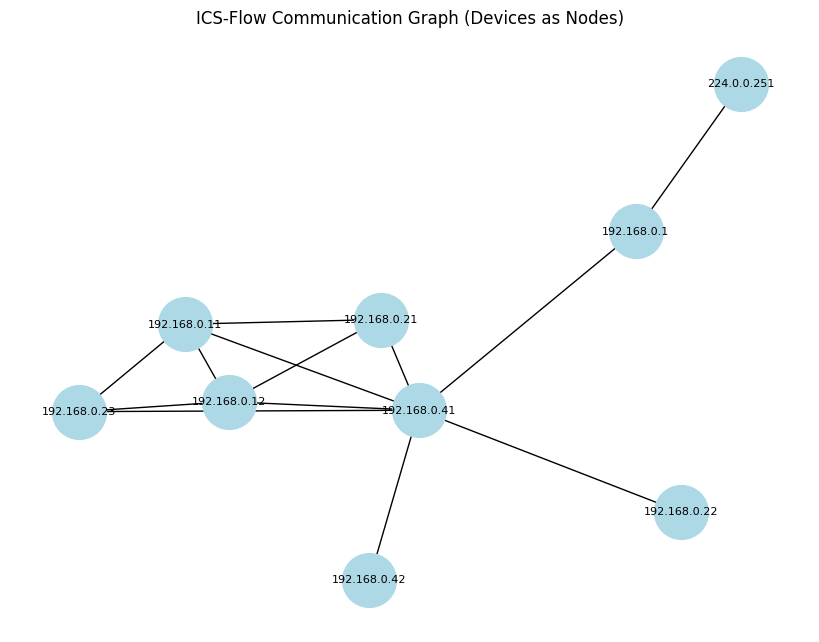

In [24]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(8, 6))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=1500,
    font_size=8
)
plt.title("ICS-Flow Communication Graph (Devices as Nodes)")
plt.savefig("week2_graph.png", dpi=150, bbox_inches="tight")
plt.show()

## **7. Exploratory Distributions — Addresses, Protocols, and Labels**

Quick value counts to understand traffic volume per device, protocol mix, and the balance of attack classes in the dataset.

In [25]:
print("Source IP traffic volume:")
print(df['sIPs'].value_counts())

print("\nDestination IP traffic volume:")
print(df['rIPs'].value_counts())

print("\nProtocol distribution:")
print(df['protocol'].value_counts())

print("\nIT_M_Label distribution (Interval-Based Threshold, multi-class):")
print(df['IT_M_Label'].value_counts())

print("\nNST_M_Label distribution (Network Signature Threshold, multi-class):")
print(df['NST_M_Label'].value_counts())

Source IP traffic volume:
sIPs
192.168.0.11    29556
192.168.0.12    13425
192.168.0.21      310
192.168.0.1       264
192.168.0.23      207
192.168.0.41      197
192.168.0.22      197
Name: count, dtype: int64

Destination IP traffic volume:
rIPs
192.168.0.21    24412
192.168.0.12    14016
192.168.0.41     4791
192.168.0.23      730
192.168.0.42      197
224.0.0.251        10
Name: count, dtype: int64

Protocol distribution:
protocol
IPV4-TCP     43984
ARP           1552
IPV4-ICMP      162
IPV6            10
IPV4-UDP        10
Name: count, dtype: int64

IT_M_Label distribution (Interval-Based Threshold, multi-class):
IT_M_Label
Normal       30236
replay        4300
ddos          4221
port-scan     3235
mitm          3014
ip-scan        712
Name: count, dtype: int64

NST_M_Label distribution (Network Signature Threshold, multi-class):
NST_M_Label
Normal       36706
mitm          2584
replay        2358
port-scan     1944
ddos          1934
ip-scan        192
Name: count, dtype: int64


**Why this matters:** the `NST_M_Label` breakdown is the first real result from this notebook — it shows exactly how imbalanced the attack classes are (Normal traffic dominates, with `mitm`, `replay`, `port-scan`, `ddos`, and `ip-scan` each making up a small minority). This class imbalance will need to be addressed (e.g. with class weighting) when training the GNN in later weeks.

## **8. Weighted Graph — Flow Count per Device Pair**

The graph in Section 5 only records *whether* two devices communicated, not *how much*. This section builds a directed, weighted version of the graph, where each edge weight is the number of flows recorded between that source and destination — a more informative input for the eventual GNN, which will use edge weight as a feature.

In [26]:
edge_weights = (
    df_graph.groupby(["sIPs", "rIPs"])
    .size()
    .reset_index(name="flow_count")
)

G_weighted = nx.DiGraph()
for _, row in edge_weights.iterrows():
    G_weighted.add_edge(row["sIPs"], row["rIPs"], weight=row["flow_count"])

print("Weighted graph — Nodes:", G_weighted.number_of_nodes())
print("Weighted graph — Edges:", G_weighted.number_of_edges())
edge_weights.sort_values("flow_count", ascending=False)

Weighted graph — Nodes: 9
Weighted graph — Edges: 13


,sIPs,rIPs,flow_count
2,192.168.0.11,192.168.0.12,14016
3,192.168.0.11,192.168.0.21,13140
6,192.168.0.12,192.168.0.21,11272
5,192.168.0.11,192.168.0.41,1922
8,192.168.0.12,192.168.0.41,1901
4,192.168.0.11,192.168.0.23,478
9,192.168.0.21,192.168.0.41,310
0,192.168.0.1,192.168.0.41,254
7,192.168.0.12,192.168.0.23,252
11,192.168.0.23,192.168.0.41,207


## **9. Attack-Aware Graph — Highlighting Malicious Edges**

Identifies which device pairs ever carried attack traffic (using `NST_M_Label`) and re-draws the graph with those edges highlighted in red. This is the step that turns a plain network diagram into a security-relevant graph — the same structure the knowledge graph will eventually encode as labelled, risk-weighted edges.

Device pairs that carried attack traffic:

            sIPs          rIPs NST_M_Label  count
0    192.168.0.1  192.168.0.41   port-scan    254
1   192.168.0.11  192.168.0.12        mitm    921
2   192.168.0.11  192.168.0.12      replay    227
3   192.168.0.11  192.168.0.21        mitm    648
4   192.168.0.11  192.168.0.21      replay    202
5   192.168.0.11  192.168.0.23        mitm     70
6   192.168.0.11  192.168.0.23      replay      6
7   192.168.0.11  192.168.0.41        ddos    968
8   192.168.0.11  192.168.0.41   port-scan    243
9   192.168.0.11  192.168.0.41      replay    711
10  192.168.0.12  192.168.0.21        mitm    390
11  192.168.0.12  192.168.0.21      replay    184
12  192.168.0.12  192.168.0.23        mitm     29
13  192.168.0.12  192.168.0.23      replay      5
14  192.168.0.12  192.168.0.41        ddos    966
15  192.168.0.12  192.168.0.41   port-scan    243
16  192.168.0.12  192.168.0.41      replay    692
17  192.168.0.21  192.168.0.41   port-scan    254
18  192

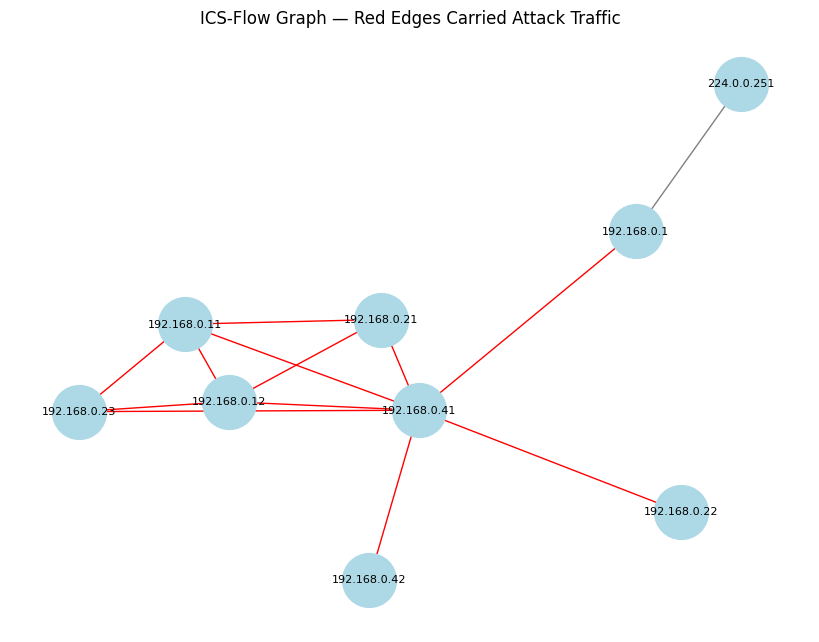

In [27]:
attack_edges = (
    df_graph[df_graph["NST_M_Label"] != "Normal"]
    .groupby(["sIPs", "rIPs", "NST_M_Label"])
    .size()
    .reset_index(name="count")
)
print("Device pairs that carried attack traffic:\n")
print(attack_edges)

# G is undirected, so check both (u, v) and (v, u) — NetworkX does not
# guarantee edges are returned in the same direction they were inserted.
attack_pairs = set(zip(attack_edges["sIPs"], attack_edges["rIPs"]))
edge_colors = [
    "red" if (u, v) in attack_pairs or (v, u) in attack_pairs else "gray"
    for u, v in G.edges()
]

plt.figure(figsize=(8, 6))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    edge_color=edge_colors,
    node_size=1500,
    font_size=8
)
plt.title("ICS-Flow Graph — Red Edges Carried Attack Traffic")
plt.savefig("week2_attack_graph.png", dpi=150, bbox_inches="tight")
plt.show()

## **10. Summary**

- Loaded `Dataset.csv` from ICS-Flow: 45,718 labelled network flows, 64 features, two labelling strategies (IT / NST).
- Built an asset-level communication graph by collapsing flow records into unique device-to-device edges (~10 nodes, ~14 edges) — a small ICSSIM testbed topology.
- Produced a weighted, directed version of the graph capturing flow volume per device pair.
- Identified and visualised which device pairs carried attack traffic (`mitm`, `replay`, `port-scan`, `ddos`, `ip-scan`), turning the plain topology into a security-relevant graph.
- Confirmed significant class imbalance in attack labels — to be addressed during GNN training in later weeks.

**Next steps (Week 3 onward):**
1. Define the knowledge-graph schema in Neo4j (Asset, Vulnerability, Technique node types).
2. Ingest MITRE ATT&CK for ICS and CVE data to enrich this network graph with technique and vulnerability nodes.
3. Convert the weighted graph built here into a `torch_geometric.data.Data` object for GNN training.
4. Begin baseline GNN training for intrusion detection on ICS-Flow, benchmarked against `zhenlus/GNN-IDS`.